# 第2回 — B0 / B1 / W1 / SSを読む・眺める・再実行する

記事の既存報告はB0 **62.841**、B1 **58.362**、W1 **66.835**。元の既存報告値です。ローカル全件再推論・固定公式再採点で主要指標が一致しました。SSは今回新規測定で **62.325（B0比−0.516ポイント）**。外部の独立追試とは主張しません。

この1冊は「保存結果閲覧」「合成デモ」「保存異常度の公式再採点」「生音声から再推論」を分けます。計算は `asd_min` のCLI共通関数で行い、Wandas **0.8.0** は可視化・手動試聴を提供します。音声と重みは読者が公式から取得します。

## 1. Setup

READMEの環境を用意し、このコピーのrootまたはnotebooksディレクトリを作業場所にします。既定では外部データ処理・採点・自動再生をしません。

In [1]:
%matplotlib inline
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import wandas as wd
from IPython.display import display
from asd_min.notebook import frames, show
from asd_min.runner import run, plan
from asd_min.evaluation import evaluate
ROOT = Path.cwd() if (Path.cwd()/"results").is_dir() else Path.cwd().parent
assert (ROOT/"results/summary-with-ss.csv").is_file()
assert wd.__version__ == "0.8.0"
ENABLE_AUDIO = False  # Trueで手動再生controlを生成。自動再生しない。
plt.rcParams.update({"font.size": 11, "figure.dpi": 100})

## 2. 保存結果閲覧（音声・重み不要）

B0/B1/W1は2026-09-21既存報告、SSは2026-10-03の新規全件実験です。既存3条件のローカル再推論・固定公式再採点では主要指標が一致しました。割合を100倍して表示します。総合値は5機種のsource/target AUCとpAUC計15値の調和平均であり、故障検出率ではありません。

source AUCはsource正常音と両domainすべての異常音、target AUCはtarget正常音と両domainすべての異常音で計算。pAUCは全テスト音のmax_fpr=0.1標準化値です。SSはB0比−0.516ポイントで総合改善はありません。詳細は[SS検証記録](../docs/ss-validation.md)。


,condition,official_score,source_auc_hmean,target_auc_hmean,pauc_hmean
0,b0,62.841,67.958,62.809,58.468
1,b1,58.362,61.558,58.892,55.010
2,w1,66.835,73.720,66.381,61.512
3,ss,62.325,67.563,61.739,58.356


condition,b0,b1,w1,ss
machine,,,,
BlowerDustCollector,72.000,59.842,73.158,73.474
Sander,51.947,49.263,55.947,52.368
SewingMachine,66.000,59.158,67.105,64.684
ToothBrush,50.158,51.368,53.211,49.632
ToyDrone,57.842,57.105,62.316,57.579


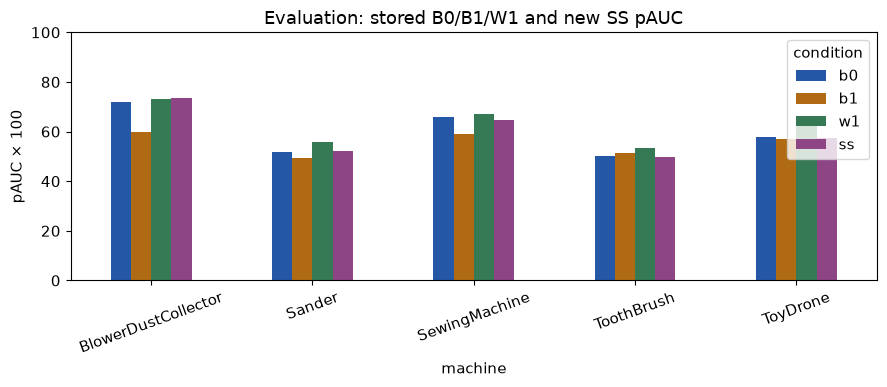

In [2]:
summary = pd.read_csv(ROOT/"results/summary-with-ss.csv").set_index("condition").reindex(["b0","b1","w1","ss"]).reset_index()
display(summary.assign(**{c:100*summary[c] for c in summary.columns if c != "condition"}).round(3))
by_machine = pd.read_csv(ROOT/"results/by_machine-with-ss.csv")
pauc = by_machine.pivot(index="machine", columns="condition", values="pauc").reindex(columns=["b0","b1","w1","ss"])*100
display(pauc.round(3))
ax=pauc.plot.bar(figsize=(9,4), rot=20, color=["#2458a6","#b16a14","#357a54","#8e4585"])
ax.set(title="Evaluation: stored B0/B1/W1 and new SS pAUC", ylabel="pAUC × 100", ylim=(0,100))
plt.tight_layout(); plt.show()

## 3. 合成デモ — Wandasで可視化・手動試聴

1kHz共通音と近接側だけの1.9kHz音を混ぜた説明用の信号です。実音や検知成績の証拠ではありません。W1の残差は共通Torch計算核（録音全体）で計算します。表示STFTはWandasなので端処理を実測W1と同一視しません。記事草稿の端2フレームを除いた合成図とも区別します。

Wandas `describe(normalize=False)` の試聴は音量関係を保持します。残差には機械音も削られる可能性があり、スコア改善と聞きやすさを同一視しません。

**追加したSS**: 近接大きさが遠方大きさより大きいときだけ差を採用し、それ以外は近接の0.1倍を残します（β=1、γ=0.1）。等しい場合も0.1倍です。正の差を常に0.1倍以上へclampする処理ではありません。近接位相を保持します。

実測用SSはHann512/hop256です。記事・原報告が指定しないperiodic/center/paddingについて、本実装はTorch periodic Hann・center=True・reflectを固定し、入力正規化は追加しません。表示用Wandas STFTは全条件1024/hop512で揃えた別解析なので、SS実測STFTとは区別してください。この記事ではQianのEAT/KNNや16秒loopingを再現しません。

SS実音全件推論・公式ローカル採点は完了しました。BEATsは公式project MITの案内に沿ったローカル推論と、checkpoint自体の再配布確認を区別します。合成図をSS検知成績の証拠にはしません。

B0 synthetic; not DCASE performance


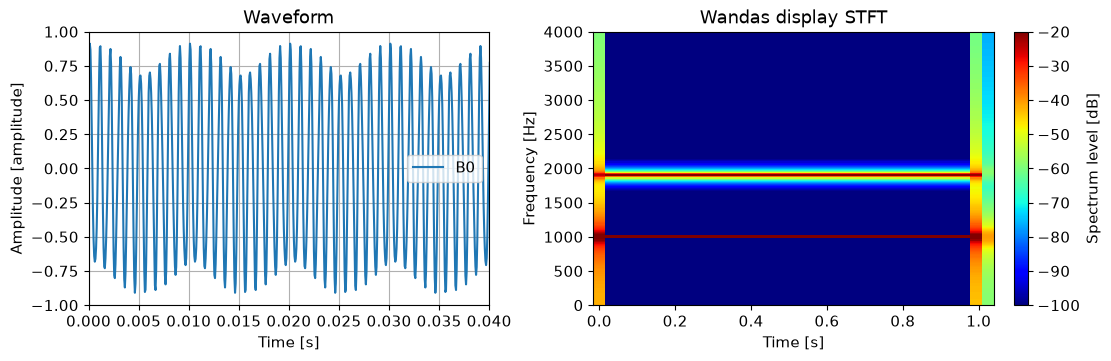

B1 synthetic; not DCASE performance


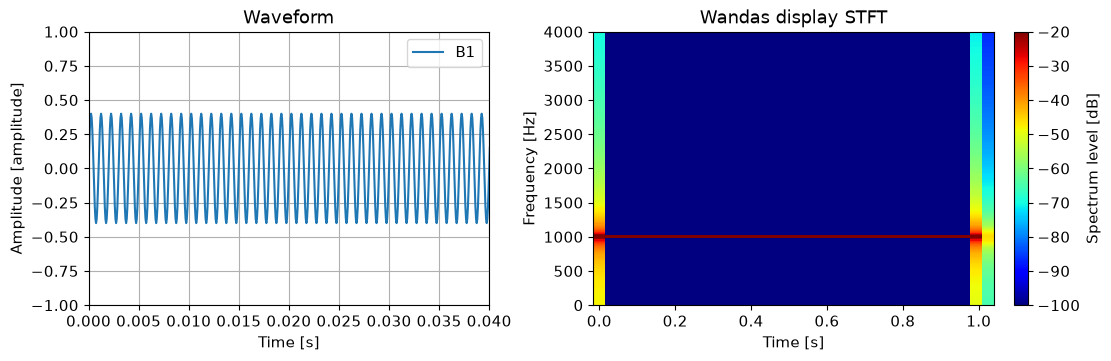

W1 synthetic; not DCASE performance


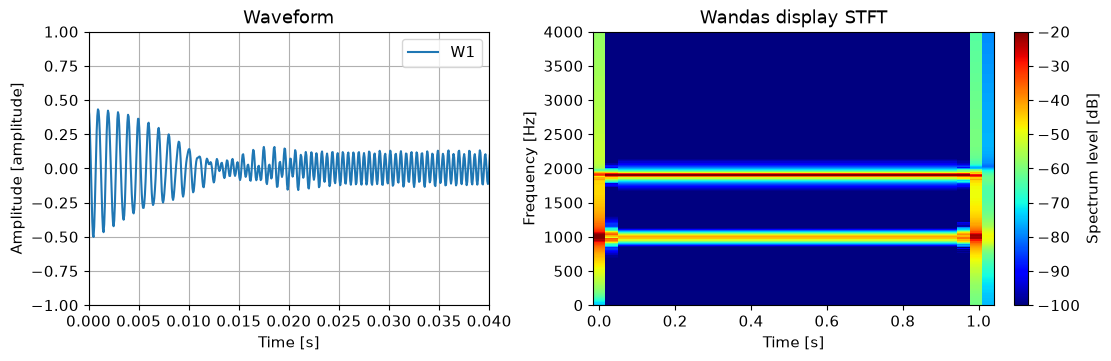

SS synthetic; not DCASE performance


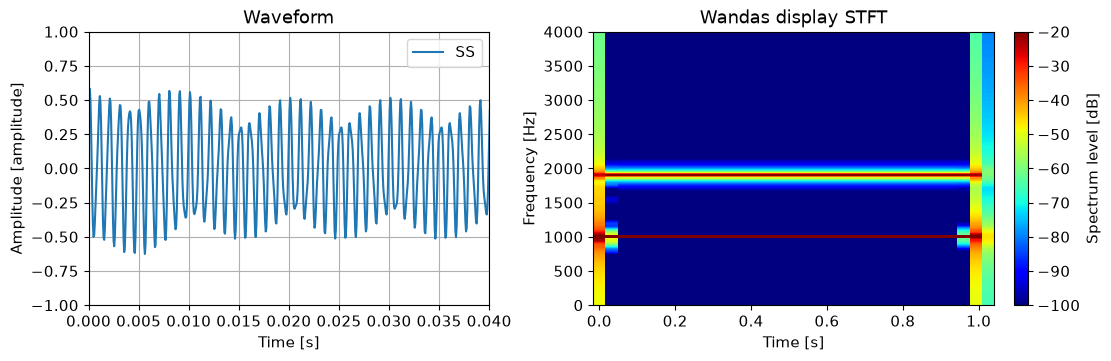

In [3]:
demo = frames()
for condition, frame in demo.items():
    print(condition.upper(), "synthetic; not DCASE performance")
    fig=show(frame, audio=False)
    display(fig); plt.close(fig)
    if ENABLE_AUDIO:
        show(frame, audio=True)

## 4. 読者の生音声を眺める（推論とは別）

公式から取得した16kHz stereo音声のpathを指定します。結果はメモリ上のみ。音声を公開Notebookに保存しないでください。Wandasの画面から音は手動再生します。

In [4]:
AUDIO_PATH = None  # Path("/path/to/eval_data/raw/ToothBrush/test/section_00_0000.wav")
if AUDIO_PATH is not None:
    for condition, frame in frames(path=AUDIO_PATH).items():
        print(condition.upper())
        fig=show(frame); display(fig); plt.close(fig)
        if ENABLE_AUDIO: show(frame,audio=True)
else:
    print("Optional real-audio inspection skipped")

Optional real-audio inspection skipped


## 5. 保存異常度を再採点（特徴再計算ではない）

[evaluator条件](../docs/rights.md)の確認・解決が必要です。evaluatorと正解CSVは同梱しません。固定コミットの無改変clean checkoutを読者が指定します。`TERMS_REVIEWED=True`は許諾取得や契約同意を代行するものではありません。既定はスキップします。

In [5]:
EVALUATOR = None  # Path("/path/to/official-evaluator")
TERMS_REVIEWED = False
RESCORE_OUTPUT = ROOT/"outputs/rescore-notebook"
if EVALUATOR is not None and TERMS_REVIEWED:
    for condition in ("b0","b1","w1","ss"):
        print(evaluate(ROOT/"results"/condition, EVALUATOR, RESCORE_OUTPUT/condition, terms_reviewed=True))
else:
    print("Official rescoring skipped: external assets and terms required")

Official rescoring skipped: external assets and terms required


## 6. 生音声から再推論（正常参照も各条件で再構築）

[入力取得とchecksum](../docs/inputs.md)、[固定実験条件](../docs/protocol.md)を確認。B0/B1/W1/SSそれぞれで正常参照を作り直します。今回のSS全件推論は完了しています。読者の再実行は次のセルで明示的に有効化します。BEATs_iter3、frequency RDP4、BEAM VarMin4 train_all/per_bandを固定します。trainのみ正常参照・閾値決定に使用し、test正解は使いません。

既定は1機種各split5件の小規模設定で、記事成績にはなりません。全件は `MACHINES=None; LIMIT=None` に変更し、機器と実測時間を確認してから有効化します。CPUが既定。CLIと同じ `run()` を呼びます。

In [6]:
DATA_ROOT = None  # Path("/path/to/eval_data/raw")
CHECKPOINT = None  # Path("/path/to/BEATs_iter3.pt")
RUN_INFERENCE = False  # 読者の取得資産・条件・資源を確認して変更
MACHINES = ("ToothBrush",)
LIMIT = 5
OUTPUT = ROOT/"outputs/notebook-inference"
if RUN_INFERENCE and DATA_ROOT is not None and CHECKPOINT is not None:
    from asd_min.runner import MACHINES as ALL_MACHINES
    selected = ALL_MACHINES if MACHINES is None else MACHINES
    print({m:{s:len(p) for s,p in v.items()} for m,v in plan(DATA_ROOT, selected, LIMIT).items()})
    receipt = run(DATA_ROOT,CHECKPOINT,OUTPUT,device="cpu",machines=selected,limit=LIMIT)
    display({k:receipt[k] for k in ("mode","status","timings_seconds")})
else:
    print("Fresh inference skipped; explicitly enable after resource check")

Fresh inference skipped; explicitly enable after resource check


## Checks / Next steps

保存表と合成デモは上から実行できます。今回のローカル全件検証と、このNotebookの任意セルを読者が実行したかは分けて扱ってください。既定実行は外部資産アクセス・再推論・公式採点をスキップします。検証範囲は[VALIDATION.md](../VALIDATION.md)。

SSは新規6000音実験と公式ローカル採点を完了。原Qianシステムとの完全同等や主観的な聞きやすさは未検証です。[SS実験記録](../docs/ss-validation.md)、[外部資産の権利条件](../docs/rights.md)を参照してください。公式evaluator・正解・音声・重みは同梱しません。
